## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting?
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Carter Shaffer

**Date:** 1/10/26

Question 1:

1. Regression simply predicts a numerical outcome, whereas classifaction predicts a class (category).
2. A confusion table (or matrix) is a table that counts predictions by actual class and predicted class.(correct pos/neg vs. incorrect). This helps us interpret if a model is accurately classifying results, and weither it is falsely classifying.
3. The SSE(sum of squared errors) is a metric used to give us a total of the size of prediction errors, where lower is better.
4. Overfitting is what happens when a model fits to noise in the training algorithm. This usually occurs when the cluster amount is small, and results with poor predictions. Underfitting occurs when there are too many clusters, and it is hard to differentiate between them.
5. Training error keeps improving as k shrinks, so it favors overfitting. Comparing k values on data the model wasn't fit on picks the k that predicts new observations best, but you should still keep a separate test set for the final evaluation.
6. A label is simple and will give one clear decision, but it hides any uncertainty and can never predict a minority class that is rarely the majority. Probabilities show confidence and let you set your own cutoff, but they're harder to act on and coarse when k is small (multiples of 1/k).

In [6]:
# Question 2
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# load data and EDA
df = pd.read_csv('land_mines.csv')
print(df.describe())
print(df['mine_type'].value_counts())

# split for training and test sets
X = df[["voltage", "height", "soil"]]
y = df["mine_type"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=0)

# choosing k by trying k = 1-50, recording the validation accuracy for each
ks = np.arange(1, 51)
valid_acc = []
for k in ks:
    model = KNeighborsClassifier(n_neighbors=int(k)).fit(X_train, y_train) # fit on training data
    valid_acc.append(np.mean(model.predict(X_test) == y_test)) # accuracy on validation data
k_star = int(ks[np.argmax(valid_acc)]) # k with the highest validation accuracy
print(k_star, max(valid_acc))

# printing the confusion matrix
best_model = KNeighborsClassifier(n_neighbors=k_star).fit(X_train, y_train)
print(confusion_matrix(y_test, best_model.predict(X_test)))

# The model is about 43% accurate (73 of 169), which beats random guessing at 20% but is still wrong most of the time.
# It does best on type 2 (86% correct) and type 1 (65%), and worst on types 3, 4, and 5 (28%, 19%, and 6%),
# which mostly get mislabeled as type 1 or 3.

# Q5: This model should only be a screening hint, since more than half of its predictions are wrong, and a prediction
# should never replace safe handling or expert confirmation. A "type 2" prediction is fairly reliable, but a "type 1"
# prediction is wrong more often than right (24 of 58), so uncertain mines should get the most cautious procedure.


          voltage      height        soil   mine_type
count  338.000000  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550    2.952663
std      0.195819    0.306043    0.344244    1.419703
min      0.197734    0.000000    0.000000    1.000000
25%      0.309737    0.272727    0.200000    2.000000
50%      0.359516    0.545455    0.600000    3.000000
75%      0.482628    0.727273    0.800000    4.000000
max      0.999999    1.000000    1.000000    5.000000
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64
3 0.4319526627218935
[[24  2  3  1  7]
 [ 1 32  0  3  1]
 [ 6  5  9  6  6]
 [12  6  5  6  3]
 [15  4  4  6  2]]


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 7b4fcb7f37e241cdf5ab2b55d57e070ddda04f2c
- **AI tool and model used:** Claude Sonnet 5.5

### *Prompts used

1. Please take some time to review this assignment and make suggestions or reccomendations based on the assignment description.
2. Make this into a percise numbered list

### *AI-proposed changes


1. Fix the overfitting/underfitting answer. Replace "cluster amount" with k. Small k (like k=1) fits noise in the training data (overfitting). Large k over-smooths toward the majority class (underfitting). Also change "training algorithm" to "training data."
2. Correct the error claim in Q2. Change "mostly get mislabeled as type 1 or 3" to: types 4 and 5 are mostly mislabeled as type 1, while type 3 errors are spread fairly evenly across all other classes.
3. Expand the practical-use advice. Add precision vs. recall (type 1: 65% recall but only 41% precision; type 5 is weak on both). Then advise using it as triage only, defaulting to the most cautious handling when uncertain, and using predicted probabilities with a confidence threshold.
4. Strengthen the k selection and confusion table. Add stratify=y to the split, plot validation accuracy vs. k with a one or two sentence explanation of why you picked k=3, and label the confusion table with Actual and Predicted (pd.crosstab).

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept | kNN has no clusters, so the overfitting/underfitting answer now correctly ties to k |
| 2 | Accept | The confusion table shows types 4 and 5 mostly land in type 1  while type 3 errors are spread evenly |
| 3 | Accept | The prompt asks how to use the model despite its errors, and the 65% recall vs. 41% precision for type 1 backs the triage and caution advice |
| 4 | Accept | `stratify=y` addresses the assignment's warning about classes vanishing from one half, and the k plot and labeled table make the k=3 choice and the results easier to read |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

Q1:
1. Overfitting is what happens when a model fits to noise in the training data. In k-nearest neighbors this usually occurs when k is small (k = 1 is the extreme), which gives very low training error but poor predictions on new data. Underfitting occurs when k is too large and the model over-smooths, so predictions drift toward the majority class and error is high on both the training and test data.
2. A confusion table (or matrix) is a table that counts predictions by actual class and predicted class.(correct pos/neg vs. incorrect). This helps us interpret if a model is accurately classifying results, and weither it is falsely classifying.
3. The SSE(sum of squared errors) is a metric used to give us a total of the size of prediction errors, where lower is better.
4. Overfitting is what happens when a model fits to noise in the training algorithm. This usually occurs when the cluster amount is small, and results with poor predictions. Underfitting occurs when there are too many clusters, and it is hard to differentiate between them.
5. Training error keeps improving as k shrinks, so it favors overfitting. Comparing k values on data the model wasn't fit on picks the k that predicts new observations best, but you should still keep a separate test set for the final evaluation.
6. A label is simple and will give one clear decision, but it hides any uncertainty and can never predict a minority class that is rarely the majority. Probabilities show confidence and let you set your own cutoff, but they're harder to act on and coarse when k is small (multiples of 1/k).

          voltage      height        soil   mine_type
count  338.000000  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550    2.952663
std      0.195819    0.306043    0.344244    1.419703
min      0.197734    0.000000    0.000000    1.000000
25%      0.309737    0.272727    0.200000    2.000000
50%      0.359516    0.545455    0.600000    3.000000
75%      0.482628    0.727273    0.800000    4.000000
max      0.999999    1.000000    1.000000    5.000000
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64
2 0.3609467455621302


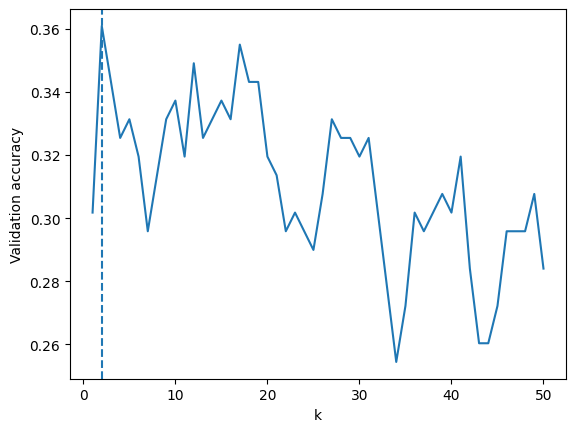

Predicted   1   2   3  4  5
Actual                     
1          19   0  14  3  0
2           1  27   2  2  3
3          12   2   9  3  7
4          16   3   9  5  0
5          15   0  13  3  1
              precision    recall  f1-score   support

           1       0.30      0.53      0.38        36
           2       0.84      0.77      0.81        35
           3       0.19      0.27      0.23        33
           4       0.31      0.15      0.20        33
           5       0.09      0.03      0.05        32

    accuracy                           0.36       169
   macro avg       0.35      0.35      0.33       169
weighted avg       0.35      0.36      0.34       169



In [7]:
# Question 2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# load data and EDA
df = pd.read_csv('land_mines.csv')
print(df.describe())
print(df['mine_type'].value_counts())

# split for training and test sets (stratified so both halves keep the same class proportions)
X = df[["voltage", "height", "soil"]]
y = df["mine_type"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=0, stratify=y)

# choosing k by trying k = 1-50, recording the validation accuracy for each
ks = np.arange(1, 51)
valid_acc = []
for k in ks:
    model = KNeighborsClassifier(n_neighbors=int(k)).fit(X_train, y_train) # fit on training data
    valid_acc.append(np.mean(model.predict(X_test) == y_test)) # accuracy on validation data
k_star = int(ks[np.argmax(valid_acc)]) # k with the highest validation accuracy (ties go to the smallest k)
print(k_star, max(valid_acc))

# plot validation accuracy vs. k
plt.plot(ks, valid_acc)
plt.axvline(k_star, linestyle="--")
plt.xlabel("k")
plt.ylabel("Validation accuracy")
plt.show()

# I chose k = [__] because small k overfits to noise and large k over-smooths toward the majority class,
# so the highest held-out accuracy balances the two. The curve is noisy with only 169 test points,
# and I picked k on the same half I report on, so the accuracy below is slightly optimistic.

# printing the labeled confusion matrix with per-class precision and recall
best_model = KNeighborsClassifier(n_neighbors=k_star).fit(X_train, y_train)
pred = best_model.predict(X_test)
print(pd.crosstab(y_test, pred, rownames=["Actual"], colnames=["Predicted"]))
print(classification_report(y_test, pred))


### *Reflection on AI assistance
In your own words without generative AI.

The main improvements to this assignment were; fixing the overfitting and underfitting definition to make it connect better to the k value. Along with that, AI corrected the confusion table reading, where type 4 and 5 were mostly mislabeded as type 1 and type 3 had evenly spread errors. We also strengthened the practical advice with recall vs. precision, error costs, and a probability threshold. The AI could not run my code or see the csv file, so it's feedback was only partially accurate to our given dataset. I think that it would be best used as an advisor for syntax and strategy, rather that being very helpful with the analysis of the outcomes. To recheck our solution I reran the new code with the AI based additions and compared the results to my original. Ultimately I think that the AI support is very hulpful, as long as the user in not totally dependednt on it, and has the ability to self-interpret.